In [3]:
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
from generating_dataset import dataset,true_beta
from palette import palette
import matplotlib.pyplot as plt

In [4]:
X,y = dataset
n,p = X.shape[0],X.shape[1]-1

### <b> EXPERIMENT 7.3.1. Variable selection across the model space

In [12]:
def compute_all_models(y, X):
    n, P = X.shape
    
    yty = y.T @ y
    results = []
    
    all_indices = list(range(P))
    
    for k in range(1, P + 1):
        for combo in combinations(all_indices, k):
            
            idx = list(combo)
            X_gamma = X[:, idx]
            p_gamma = k
            
            XtX = X_gamma.T @ X_gamma
            Xty = X_gamma.T @ y
            
        
            beta_hat = np.linalg.solve(XtX, Xty)
            b1_term = yty - (n / (n + 1)) * (Xty.T @ beta_hat)
            
            log_ml = -0.5 * p_gamma * np.log(1 + n) - (n / 2) * np.log(b1_term)
            
            results.append({
                'selection': tuple(combo), 
                'size_p': p_gamma,
                'log_ml': float(log_ml)
            })
            
    return pd.DataFrame(results)


def get_map_model(results_df):
    map_index = results_df['log_ml'].idxmax()
    map_model = results_df.loc[map_index]
    
    print("\n--- MAP MODEL ---")
    print(f"Selected Indices (0 = Intercept): {map_model['selection']}")
    print(f"Model Size (P): {map_model['size_p']}")
    print(f"Log-ML: {map_model['log_ml']:.4f}")
    
    return map_model


def get_pip_and_mpm(results_df, P):
    max_log_ml = results_df['log_ml'].max()
    weights = np.exp(results_df['log_ml'] - max_log_ml)
    results_df['PMP'] = weights / weights.sum()
    
    pips = {}
    for j in range(P):
        pip_j = results_df[results_df['selection'].apply(lambda s: j in s)]['PMP'].sum()
        name = "Intercept (X0)" if j == 0 else f"X{j}"
        pips[name] = float(pip_j)
        
    print("\n--- POSTERIOR INCLUSION PROBABILITIES (PIP) ---")
    for var, prob in pips.items():
        print(f"{var}: {prob:.4f}")
        
    
    return pips, results_df

In [13]:
models_df = compute_all_models(y,X)
pips, models_df = get_pip_and_mpm(models_df,11)


--- POSTERIOR INCLUSION PROBABILITIES (PIP) ---
Intercept (X0): 0.9984
X1: 1.0000
X2: 1.0000
X3: 1.0000
X4: 0.6171
X5: 0.0911
X6: 0.1019
X7: 0.0963
X8: 0.1098
X9: 0.0953
X10: 0.0927


C:\Users\anton\AppData\Local\Temp\ipykernel_11660\1091820355.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='PMP', y='model_label', data=top_10_models, palette='viridis', edgecolor='black')


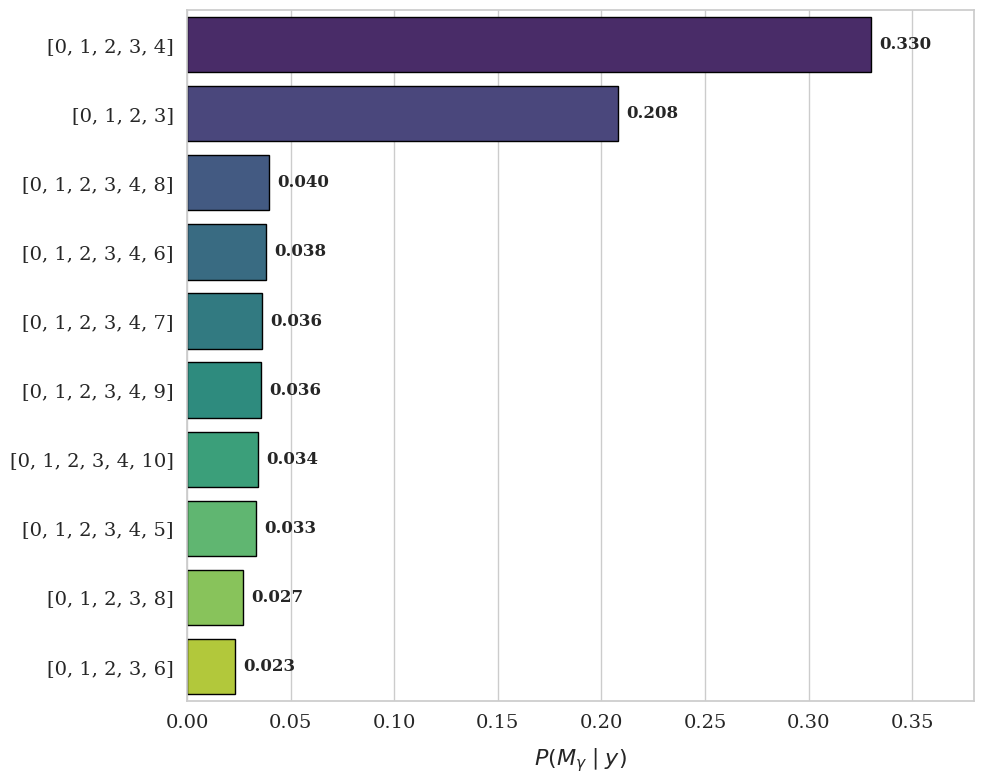

In [14]:
sns.set_theme(style="whitegrid", font="serif")

top_10_models = models_df.sort_values(by='PMP', ascending=False).head(10)

top_10_models['model_label'] = top_10_models['selection'].apply(lambda s: f"[{', '.join(map(str, s))}]")

plt.figure(figsize=(10, 8))
barplot = sns.barplot(x='PMP', y='model_label', data=top_10_models, palette='viridis', edgecolor='black')

plt.ylabel("") 
plt.xlabel(r"$P(M_\gamma \mid y)$", fontsize=16, labelpad=10)


plt.xticks(fontsize=14) 
plt.yticks(fontsize=14)


max_pmp = top_10_models['PMP'].max()
plt.xlim(0, max_pmp * 1.15) 

for p in barplot.patches:
    width = p.get_width()
    if width > 0.001: 
        barplot.annotate(f'{width:.3f}', 
                         (width, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', 
                         xytext=(6, 0),
                         textcoords='offset points', 
                         fontsize=12,
                         fontweight='bold')

plt.tight_layout()
plt.savefig('../graphics/top_10models.pdf', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\anton\AppData\Local\Temp\ipykernel_11660\1437087221.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12, loc='lower right')


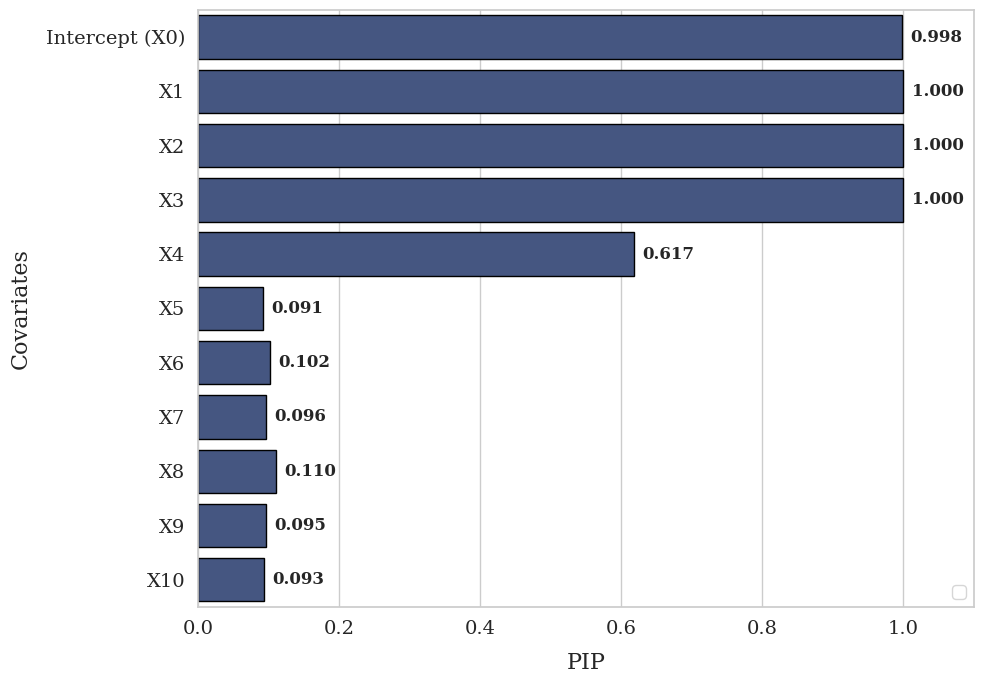

In [15]:
pip_df = pd.DataFrame(list(pips.items()), columns=['Variable', 'PIP'])

sns.set_theme(style="whitegrid", font="serif")
plt.figure(figsize=(10, 7)) 


barplot = sns.barplot(x='PIP', y='Variable', data=pip_df, color=palette.bars, edgecolor='black')



plt.xlabel("PIP", fontsize=16, labelpad=10)
plt.ylabel("Covariates", fontsize=16, labelpad=10)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 1.1) 

for p in barplot.patches:
    width = p.get_width()
    if width > 0.001:
        barplot.annotate(f'{width:.3f}', 
                         (width, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', 
                         xytext=(6, 0), 
                         textcoords='offset points', 
                         fontsize=12,
                         fontweight='bold')

plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.savefig('../pip_barchart.pdf', dpi=300, bbox_inches='tight')
plt.show()



### <b> Experiment 7.3.2 Bayes Factor 

In [16]:
models_without_4 = models_df[models_df['selection'] == (0, 1, 2, 3)]
models_with_4 = models_df[models_df['selection'] == (0, 1, 2, 3, 4)]

In [17]:
models_without_4["PMP"]

231    0.208043
Name: PMP, dtype: float64

In [18]:
models_with_4["PMP"]

561    0.330294
Name: PMP, dtype: float64